# Super-Resolution Exercises with deep neural networks

## Exercise 1: Create your own neural network for SR

**Objective:** Implement a convolutional neural network for data super-resolution. You can try with different architectures, including residual and dense connections.

**Tasks:**
1. Define the network.
2. Load an image (you can use UCMerced).
2. Downsample the image.
3. Apply the neural network for upsampling.
4. Display the results.
5. Calculate the PSNR and SSIM measures.

**Code**

In [8]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [9]:
# 1. Define the network
class SimpleSRNet(nn.Module):
    def __init__(self):
        super(SimpleSRNet, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Upsample(scale_factor=4, mode='bilinear', align_corners=False)  # Upsample at the end
        )
    
    def forward(self, x):
        return self.net(x)

In [10]:
# 2. Load an image
def load_image(image_path, size=(256, 256)):
    image = Image.open(image_path).convert('RGB')
    image = image.resize(size, Image.BICUBIC)
    transform = transforms.ToTensor()
    return transform(image).unsqueeze(0).to(device)  # (1, C, H, W)

# 3. Downsample the image
def downsample(image, scale_factor):
    return F.interpolate(image, scale_factor=1/scale_factor, mode='bilinear', align_corners=False)

In [11]:
# 4. Display results
def display_images(original, lr, sr):
    original = original.squeeze().cpu().detach().numpy().transpose(1,2,0)
    lr = lr.squeeze().cpu().detach().numpy().transpose(1,2,0)
    sr = sr.squeeze().cpu().detach().numpy().transpose(1,2,0)

    original = np.clip(original, 0, 1)
    lr = np.clip(lr, 0, 1)
    sr = np.clip(sr, 0, 1)
    
    fig, axs = plt.subplots(1, 3, figsize=(15,5))
    axs[0].imshow(original)
    axs[0].set_title('Original HR Image')
    axs[0].axis('off')

    axs[1].imshow(lr)
    axs[1].set_title('Low Resolution')
    axs[1].axis('off')

    axs[2].imshow(sr)
    axs[2].set_title('Super-Resolved Image')
    axs[2].axis('off')

    plt.show()

# 5. PSNR and SSIM calculation
def calculate_metrics(original, restored):
    """
    original, restored: torch tensors (1, C, H, W)
    """
    original = original.squeeze().cpu().numpy().transpose(1,2,0)
    restored = restored.squeeze().cpu().detach().numpy().transpose(1,2,0)
    original = np.clip(original, 0, 1)
    restored = np.clip(restored, 0, 1)

    psnr_val = psnr(original, restored, data_range=1.0)

    # Set win_size smaller if image is very small
    min_dim = min(original.shape[0], original.shape[1])
    if min_dim < 7:
        ssim_val = ssim(original, restored, data_range=1.0, channel_axis=-1, win_size=min_dim//2 * 2 + 1)
    else:
        ssim_val = ssim(original, restored, data_range=1.0, channel_axis=-1)

    return psnr_val, ssim_val


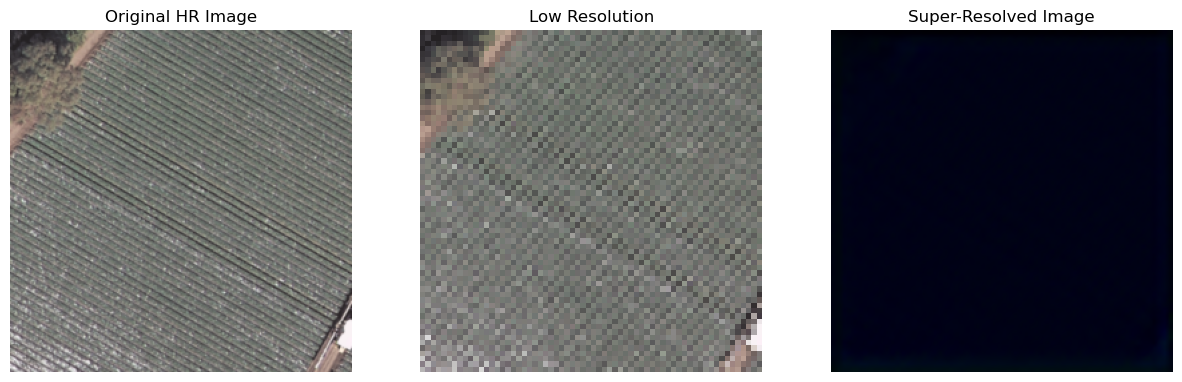

PSNR: 7.33 dB
SSIM: 0.0282


In [12]:
# ================================
# RUN EVERYTHING
# ================================

# Load image
image_path = './UCMerced_LandUse/Images/agricultural/agricultural00.tif'  
hr_image = load_image(image_path)

# Create low-res version
lr_image = downsample(hr_image, scale_factor=4)

# Initialize and run model
model = SimpleSRNet().to(device)
model.eval()

with torch.no_grad():
    sr_image = model(lr_image)

# Display
display_images(hr_image, lr_image, sr_image)

# Calculate metrics
psnr_value, ssim_value = calculate_metrics(hr_image, sr_image)
print(f"PSNR: {psnr_value:.2f} dB")
print(f"SSIM: {ssim_value:.4f}")